# pymicromegas Demo

This notebook demonstrates a real relic-density calculation with the bundled micrOMEGAs 7.1 source tree and the `SingletDM` sample model. The scan below follows the parameter choices used for the $\Omega h^2$ curves in Fig. 4 of arXiv:1105.1654, using the micrOMEGAs freeze-in routine through the `MicrOmegas` class.


## 1. Check the execution environment and dependencies

Check Python, the OS, and basic commands such as `make` and a C compiler, which are needed to build and run micrOMEGAs.


In [41]:
from __future__ import annotations

import platform
import shutil
import subprocess
import sys
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = Path("/Users/gomeshun/workspace/pymicromegas")

SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


def run_command(command, cwd=None, check=False):
    return subprocess.run(
        command,
        cwd=cwd,
        shell=isinstance(command, str),
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        check=check,
    )


def first_line(text):
    lines = (text or "").splitlines()
    return lines[0] if lines else ""


env_df = pd.DataFrame(
    [
        {"item": "Python", "value": sys.version.split()[0]},
        {"item": "Executable", "value": sys.executable},
        {"item": "Platform", "value": platform.platform()},
        {"item": "Repository", "value": str(REPO_ROOT)},
    ]
)

tool_rows = []
for name in ["make", "cc", "gcc", "clang", "curl", "wget"]:
    path = shutil.which(name)
    version = ""
    if path:
        probe = run_command([path, "--version"])
        version = first_line(probe.stdout) or first_line(probe.stderr)
    tool_rows.append(
        {
            "command": name,
            "available": bool(path),
            "path": path or "",
            "version": version,
        }
    )

display(env_df)
display(pd.DataFrame(tool_rows))

,item,value
0,Python,3.14.0b4
1,Executable,/Users/gomeshun/workspace/pymicromegas/.venv/b...
2,Platform,macOS-26.5-arm64-arm-64bit-Mach-O
3,Repository,/Users/gomeshun/workspace/pymicromegas


,command,available,path,version
0,make,True,/usr/bin/make,GNU Make 3.81
1,cc,True,/usr/bin/cc,Apple clang version 12.0.5 (clang-1205.0.22.9)
2,gcc,True,/usr/bin/gcc,Apple clang version 12.0.5 (clang-1205.0.22.9)
3,clang,True,/usr/bin/clang,Apple clang version 12.0.5 (clang-1205.0.22.9)
4,curl,True,/usr/bin/curl,curl 8.7.1 (x86_64-apple-darwin25.0) libcurl/8...
5,wget,False,,


## 2. Locate the micrOMEGAs source

`pymicromegas` bundles micrOMEGAs 7.1 as package data. This demo uses the local bundled source tree instead of downloading anything during notebook execution.


In [34]:
import importlib

import pymicromegas.pymicromegas as pm_core

pm_core = importlib.reload(pm_core)
MICROMEGAS_DIR = pm_core.MICROMEGAS_DIR
MICROMEGAS_VERSION = pm_core.MICROMEGAS_VERSION
MicrOmegas = pm_core.MicrOmegas
Project = pm_core.Project
PyMicrOmegas = pm_core.PyMicrOmegas

interface = PyMicrOmegas()
micromegas_dir = Path(MICROMEGAS_DIR).resolve()
source_note = f"micrOMEGAs {MICROMEGAS_VERSION} bundled under {micromegas_dir.relative_to(REPO_ROOT)}"

source_df = pd.DataFrame(
    [
        {"item": "version", "value": MICROMEGAS_VERSION},
        {"item": "source", "value": source_note},
        {"item": "path", "value": str(micromegas_dir)},
        {"item": "exists", "value": micromegas_dir.is_dir()},
        {"item": "already built", "value": interface.is_micromegas_built()},
    ]
)

display(source_df)
if not micromegas_dir.is_dir():
    raise FileNotFoundError(f"micrOMEGAs source tree is missing: {micromegas_dir}")

,item,value
0,version,7.1
1,source,micrOMEGAs 7.1 bundled under src/pymicromegas/...
2,path,/Users/gomeshun/workspace/pymicromegas/src/pym...
3,exists,True
4,already built,True


## 3. Configure the arXiv:1105.1654 freeze-in scan

Fig. 4 of the paper plots $\Omega h^2$ versus the singlet mass for $m_h = 120\,\mathrm{GeV}$ and several Higgs-portal couplings. In the bundled `SingletDM` model, the paper's portal coupling $\lambda$ corresponds to `laSH`.


In [26]:
import numpy as np

MODEL_NAME = "SingletDM"
BASE_PARAMETERS = {
    "Q": 100.0,
    "Mh": 120.0,
    "laS": 0.0,
}
LAMBDA_VALUES = [3e-11, 1e-11, 3e-12]
MASS_GRID = np.geomspace(0.1, 1000.0, 36)
WMAP7_OMEGA_H2 = 0.1123
WMAP7_2SIGMA = (0.105, 0.119)

scan_setup_df = pd.DataFrame(
    [
        {"item": "model", "value": MODEL_NAME},
        {"item": "scenario", "value": "FreezeIn"},
        {"item": "reference", "value": "arXiv:1105.1654 Fig. 4"},
        {"item": "Mh", "value": BASE_PARAMETERS["Mh"]},
        {
            "item": "laSH values",
            "value": ", ".join(f"{value:.0e}" for value in LAMBDA_VALUES),
        },
        {
            "item": "Mdm1 range",
            "value": f"{MASS_GRID[0]:.1f} to {MASS_GRID[-1]:.0f} GeV",
        },
    ]
)

display(scan_setup_df)

,item,value
0,model,SingletDM
1,scenario,FreezeIn
2,reference,arXiv:1105.1654 Fig. 4
3,Mh,120.0
4,laSH values,"3e-11, 1e-11, 3e-12"
5,Mdm1 range,0.1 to 1000 GeV


## 4. Run a reference freeze-in point

Use the main `MicrOmegas` class. `dark_omega` remains the freeze-out calculation, while `dark_omega_freeze_in` calls micrOMEGAs `darkOmegaFi` after marking the singlet as a feeble particle.


In [35]:
model = MicrOmegas(MODEL_NAME)

reference_point = {**BASE_PARAMETERS, "laSH": 1e-11, "Mdm1": 70.0}
reference_result = model.dark_omega_freeze_in(reference_point, channels=True)
reference_df = pd.DataFrame(
    [
        {
            **reference_point,
            "particle": reference_result["particle"],
            "TR": reference_result["TR"],
            "Omega_h2": reference_result["Omega"],
            "err": reference_result["err"],
        }
    ]
)
reference_channels_df = pd.DataFrame(reference_result["channels"])

candidate_mass = model.lib.pymicromegas_mcdm1()
metadata_df = pd.DataFrame(
    [
        {
            "model": MODEL_NAME,
            "candidate": reference_result["particle"],
            "mass": candidate_mass,
            "is_feeble": model.is_feeble(reference_result["particle"]),
        }
    ]
)

display(metadata_df)
display(reference_df)
display(reference_channels_df.head(8))

,model,candidate,mass,is_feeble
0,SingletDM,~x1,70.0,True


,Q,Mh,laS,laSH,Mdm1,particle,TR,Omega_h2,err
0,100.0,120.0,0.0,1.000000e-11,70.0,~x1,1.000000e+10,0.119307,0


,weight,in,out
0,0.526700,"(W-, W+)","(~x1, ~x1)"
1,0.234900,"(h, h)","(~x1, ~x1)"
2,0.216400,"(Z, Z)","(~x1, ~x1)"
3,0.020520,"(T, t)","(~x1, ~x1)"
4,0.000686,"(B, b)","(~x1, ~x1)"
5,0.000683,"(G, G)","(~x1, ~x1)"
6,0.000080,"(L, l)","(~x1, ~x1)"
7,0.000033,"(C, c)","(~x1, ~x1)"


## 5. Scan the Fig. 4 parameter set

Scan the same portal couplings used in the paper: $3\times10^{-11}$, $10^{-11}$, and $3\times10^{-12}$. The loop uses `tqdm.notebook` so the running progress is visible while micrOMEGAs evaluates each mass point.


In [ ]:
from tqdm import tqdm

scan_points = [
    (lambda_value, float(mdm1)) for lambda_value in LAMBDA_VALUES for mdm1 in MASS_GRID
]

scan_rows = []
for lambda_value, mdm1 in tqdm(scan_points, desc="Freeze-in scan", unit="point"):
    point = {**BASE_PARAMETERS, "laSH": lambda_value, "Mdm1": mdm1}
    result = model.dark_omega_freeze_in(point)
    scan_rows.append(
        {
            "lambda": lambda_value,
            "Mdm1": mdm1,
            "Omega_h2": result["Omega"],
            "err": result["err"],
        }
    )

scan_df = pd.DataFrame(scan_rows)
summary_rows = []
for lambda_value, group in scan_df.groupby("lambda", sort=False):
    closest_index = (group["Omega_h2"] - WMAP7_OMEGA_H2).abs().idxmin()
    closest = group.loc[closest_index]
    in_band = group[group["Omega_h2"].between(*WMAP7_2SIGMA)]
    summary_rows.append(
        {
            "lambda": lambda_value,
            "closest_Mdm1": closest["Mdm1"],
            "closest_Omega_h2": closest["Omega_h2"],
            "max_err": group["err"].max(),
            "sampled_points_in_WMAP7_2sigma": len(in_band),
        }
    )

scan_summary_df = pd.DataFrame(summary_rows)

display(scan_df.head(12))
display(scan_summary_df)

simpson warnings:Lost of precision.


simpson warnings:Lost of precision.


simpson warnings:Lost of precision.


simpson warnings:Lost of precision.


simpson warnings:Lost of precision.


...

simpson warnings:Lost of precision.


simpson warnings:Lost of precision.


Freeze-in scan: 100%|██████████| 108/108 [09:51<00:00,  5.48s/point]


,lambda,Mdm1,Omega_h2,err
0,3.000000e-11,0.100000,0.322041,0
1,3.000000e-11,0.130103,0.418983,0
2,3.000000e-11,0.169267,0.545107,0
3,3.000000e-11,0.220220,0.709196,0
4,3.000000e-11,0.286512,0.922678,0
5,3.000000e-11,0.372759,1.200418,0
6,3.000000e-11,0.484969,1.561754,0
7,3.000000e-11,0.630957,2.031836,0
8,3.000000e-11,0.820891,2.643369,0
9,3.000000e-11,1.068000,3.438863,0


,lambda,closest_Mdm1,closest_Omega_h2,max_err,sampled_points_in_WMAP7_2sigma
0,3.000000e-11,0.100000,0.322041,0,0
1,1.000000e-11,71.968567,0.121588,0,0
2,3.000000e-12,3.059950,0.098416,0,0


## 6. Inspect WMAP-compatible sampled points

The scan is coarse, so this table is a quick check of sampled masses that land inside the WMAP7 band rather than a precision contour finder.


In [ ]:
compatible_df = scan_df[scan_df["Omega_h2"].between(*WMAP7_2SIGMA)].copy()
compatible_df["lambda_label"] = compatible_df["lambda"].map(
    lambda value: f"{value:.0e}"
)
compatible_df = compatible_df[["lambda_label", "Mdm1", "Omega_h2"]].reset_index(
    drop=True
)

if compatible_df.empty:
    nearest_df = scan_summary_df.copy()
    nearest_df["lambda_label"] = nearest_df["lambda"].map(lambda value: f"{value:.0e}")
    nearest_df = nearest_df[
        [
            "lambda_label",
            "closest_Mdm1",
            "closest_Omega_h2",
            "sampled_points_in_WMAP7_2sigma",
        ]
    ]
    display(nearest_df)
else:
    display(compatible_df)

,lambda_label,closest_Mdm1,closest_Omega_h2,sampled_points_in_WMAP7_2sigma
0,3e-11,0.100000,0.322041,0
1,1e-11,71.968567,0.121588,0
2,3e-12,3.059950,0.098416,0


## 7. Visualize the relic-density curves

This reproduces the qualitative structure of the paper plot: the $\lambda^2$ scaling, a sharp change near the Higgs resonance, and an almost flat high-mass branch.


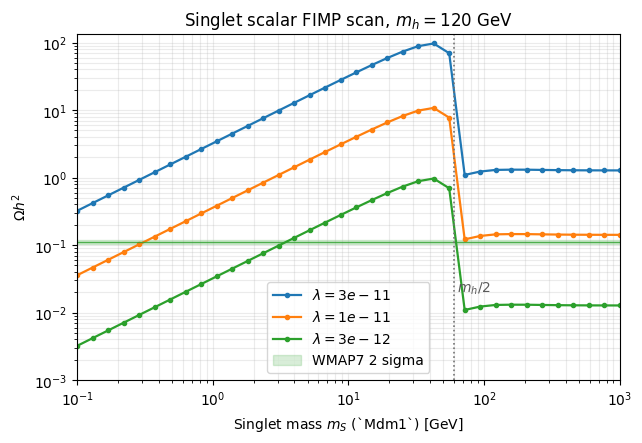

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
for lambda_value in LAMBDA_VALUES:
    subset = scan_df[scan_df["lambda"] == lambda_value]
    ax.loglog(
        subset["Mdm1"],
        subset["Omega_h2"],
        marker="o",
        markersize=3,
        linewidth=1.6,
        label=rf"$\lambda = {lambda_value:.0e}$",
    )

ax.axhspan(
    WMAP7_2SIGMA[0],
    WMAP7_2SIGMA[1],
    color="tab:green",
    alpha=0.18,
    label="WMAP7 2 sigma",
)
ax.axhline(WMAP7_OMEGA_H2, color="tab:green", linewidth=1.0, alpha=0.8)
ax.axvline(BASE_PARAMETERS["Mh"] / 2, color="0.45", linestyle=":", linewidth=1.2)
ax.text(BASE_PARAMETERS["Mh"] / 2 * 1.05, 2e-2, r"$m_h / 2$", color="0.35")
ax.set_xlabel(r"Singlet mass $m_S$ (`Mdm1`) [GeV]")
ax.set_ylabel(r"$\Omega h^2$")
ax.set_title(r"Singlet scalar FIMP scan, $m_h = 120$ GeV")
ax.set_xlim(MASS_GRID[0], MASS_GRID[-1])
ax.set_ylim(1e-3, max(scan_df["Omega_h2"]) * 1.4)
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.show()

The original paper notes that ordinary WIMP freeze-out codes cannot be applied directly to this FIMP regime. Here the scan uses the freeze-in path available in the bundled micrOMEGAs 7.1 source; small numerical differences from the 2011 plot are expected because this notebook uses the current bundled implementation rather than the paper author's private Boltzmann solver.
